In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [42]:
#Load the data
data_path ="../data/creditcard.csv"
df = pd.read_csv(data_path)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### (284807 , 31) == (rows, feature (colums))

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### No missing values
### All features are numeric.
### PCA has anonymization

In [44]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


count → shows if there are missing values

mean → shows the average value of the feature

std (standard deviation) → shows how spread the data is

min / max → used to check possible outliers

25%, 50%, 75% (quartiles) → show where most of the data is concentrated

👉 Outlier check:
If there is a big difference between the 75% value and the max value, it may indicate outliers.

👉 Important observation:

Most features are centered around 0 (because of PCA transformation)
Amount has a different scale compared to other features → scaling is required

In [45]:
print(df.dtypes)


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [46]:
print(df.isnull().sum())


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [47]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### ACCURACY = 284,315 / 284,807 ≈ 0.9983

In [48]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### %99.83 normal %0.17 fraud 
This number is the most critical fact of the project — almost 1 out of every 600 transactions is fraud. So even if the model says "everything is normal," it will achieve 99.83% accuracy but will be useless. That's why we will use Precision/Recall/F1 instead of Accuracy.

In [49]:
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

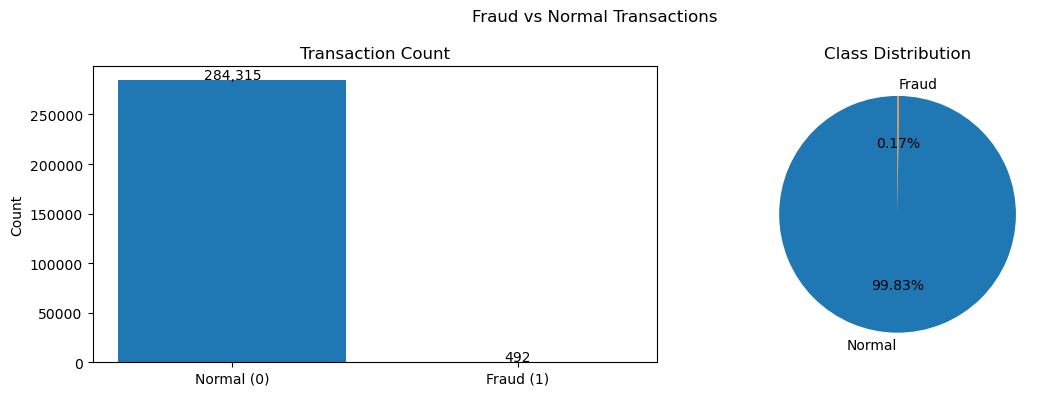

In [70]:
fig, axes =plt.subplots(1,2, figsize=(12,4))

# left: bar chart
axes[0].bar(['Normal (0)', 'Fraud (1)'],fraud_counts.values)
axes[0].set_title('Transaction Count')
axes[0].set_ylabel('Count')
for i,v in enumerate(fraud_counts.values):
    axes[0].text(i,v +1000, f'{v:,}',ha='center', fontsize=10)


# right: pie chart
axes[1].pie(fraud_counts.values,labels=['Normal', 'Fraud'], autopct='%1.2f%%',startangle=90)
axes[1].set_title('Class Distribution')

plt.suptitle('Fraud vs Normal Transactions')
plt.tight_layout()
plt.savefig('../artifacts/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Dataset is highly imbalanced, so accuracy alone is not reliable.

In [51]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


The transaction amount is highly skewed with most values being small, while a few transactions have extremely high values. This indicates the presence of outliers, and scaling will be required before training the model.

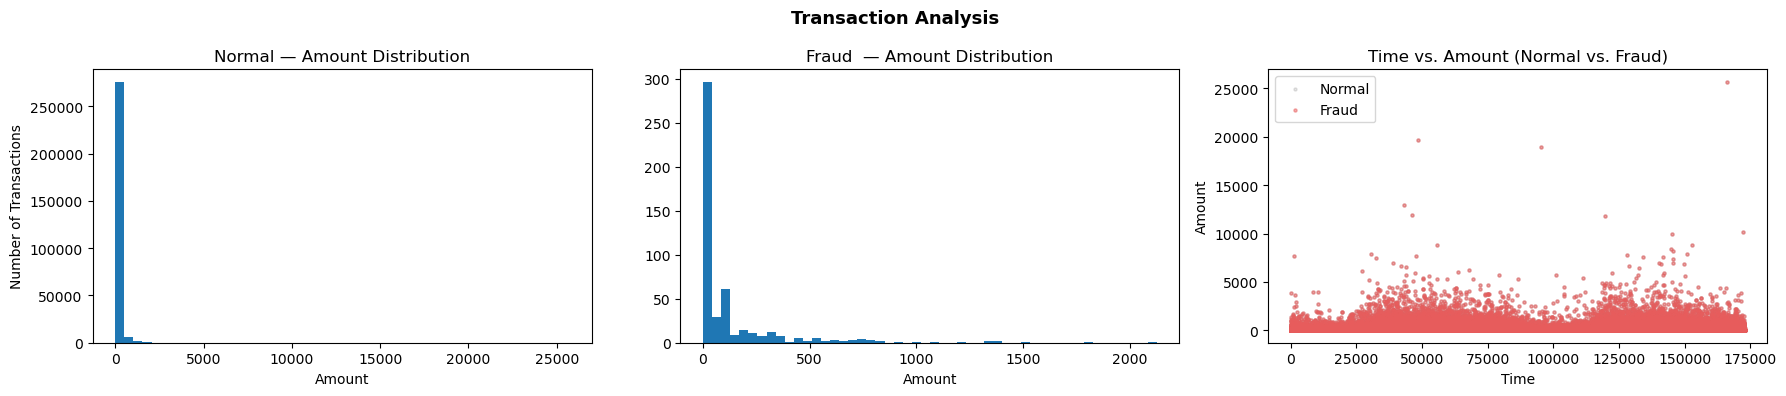

In [71]:
fig, axes= plt.subplots(1,3, figsize=(18,4))

# 1. Standard transaction amounts
axes[0].hist(df[df['Class']==0]['Amount'],bins=50)
axes[0].set_title('Normal — Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Number of Transactions')


# 2. Fraud transaction amounts
axes[1].hist(df[df['Class']==1]['Amount'],bins=50)
axes[1].set_title('Fraud  — Amount Distribution')
axes[1].set_xlabel('Amount')

# 3. Distribution of fraud over time.
axes[2].scatter( 
    df[df['Class']==0]['Time'],df[df['Class'] == 0]['Amount'] , alpha =0.1, s=5, color="#0C0C0C", label='Normal'
)
axes[2].scatter( 
    df[df['Class']==0]['Time'],df[df['Class'] == 0]['Amount'] , alpha =0.5, s=5,color='#E85D5D', label='Fraud'
)
axes[2].set_title('Time vs. Amount (Normal vs. Fraud)')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Amount')
axes[2].legend()

plt.suptitle('Transaction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/transaction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


#### 📊 **1. Normal Transactions — Amount Distribution**

👉 Observation:
- The vast majority of transactions are concentrated in low amounts.
- The distribution is right-skewed.
- High-amount transactions are very rare.

#### 📊 **2. Fraud Transactions — Amount Distribution**

👉 Observation:

- Fraud transactions are also mostly in low amounts.
- Very few data points (imbalance is clearly visible).
- Some medium and high-amount fraud transactions exist.

#### 📊 **3. Time vs Amount (Scatter Plot)**

👉 Observation:

- Fraud points are distributed over time.
- No concentration in a specific time interval.
- Fraud transactions are seen in different amount ranges.
- Normal and fraud points are mixed.

The visualizations show that both normal and fraudulent transactions are mostly concentrated in low transaction amounts. Fraud cases are distributed across different time and amount ranges, without a clear pattern.

This indicates that transaction amount alone is not sufficient to distinguish fraud. Therefore, the model must rely on multiple features (V1–V28) to detect complex patterns.

In [74]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

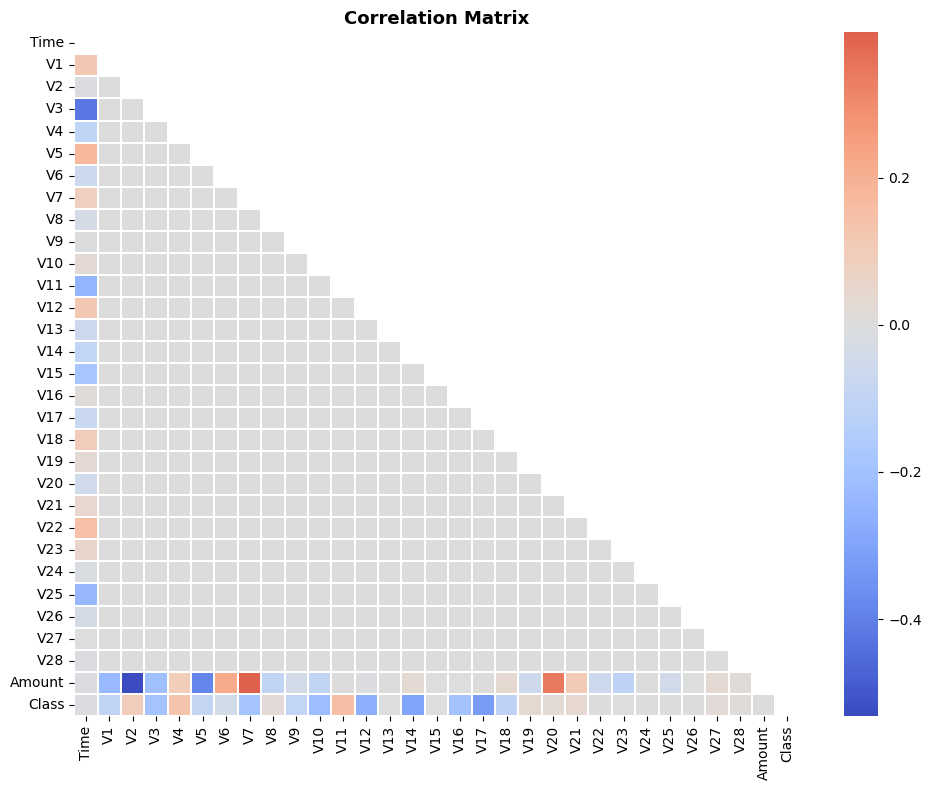

In [83]:
plt.figure(figsize=(10,8))
corr = df.corr()
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)]=True

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title("Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



The correlation matrix shows that most features have very low linear correlation with each other and with the target variable (Class). This is expected due to PCA transformation.

No single feature strongly explains fraudulent behavior, indicating that fraud detection requires combining multiple features and learning complex patterns.